In [6]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

iso = pd.read_csv('iso_matches/merged_iso_age_6.50.csv')

In [15]:
iso.sort_values(by=['mass'], inplace=True, ascending=True)

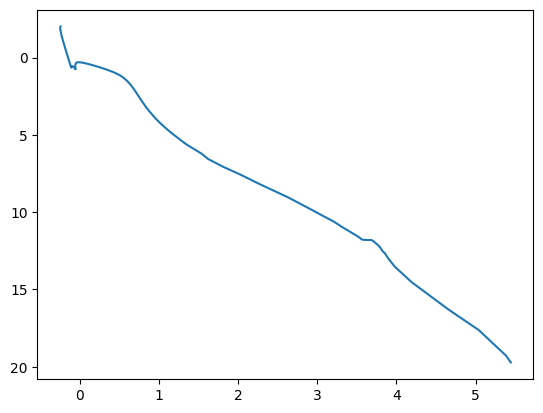

In [19]:
plt.plot(iso['VminusI'][:30000], iso['V'][:30000])
plt.gca().invert_yaxis()

Detected columns:
 BHAC: age=Age, mass=M/Ms, V=Mv, I=Mi
 PARSEC: age=logAge, mass=Mini, V=Vmag, I=Imag


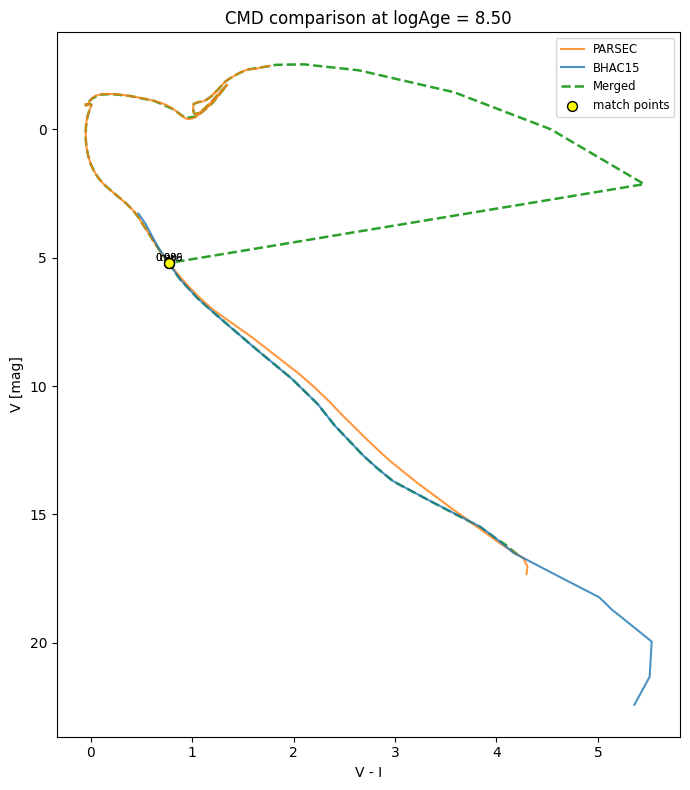

Saved compare plot to compare_age_6.50.png


In [3]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import re

# ------------- helpers to read messy isochrone files -------------
def read_isochrone_with_header(fname):
    """Read an isochrone file that uses commented header lines.
    Returns a pandas DataFrame (tries to recover column names from last comment line)."""
    fname = Path(fname)
    header_lines = []
    with open(fname, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if line.strip().startswith('#'):
                header_lines.append(line.rstrip('\n'))
            else:
                break
    # try to find the last comment line that looks like column names
    col_line = None
    for hl in reversed(header_lines):
        s = hl.lstrip('#').strip()
        tokens = re.split(r'\s+', s)
        if len(tokens) >= 4 and any(k in s for k in ['logAge','Age','Mini','M/Ms','Mv','Vmag','Teff','V','I']):
            col_line = s
            break
    colnames = re.split(r'\s+', col_line) if col_line else None
    # read numeric table skipping comments
    df = pd.read_csv(fname, comment='#', delim_whitespace=True, header=None, engine='python')
    if colnames is not None and df.shape[1] == len(colnames):
        df.columns = colnames
    else:
        # fallback to generic names
        df.columns = [f'c{i}' for i in range(df.shape[1])]
    return df

def detect_column(df, candidates, fallback_range=None):
    """Find first column name in candidates present in df. If none, try numeric heuristic using fallback_range (tuple)."""
    for c in candidates:
        if c in df.columns:
            return c
    if fallback_range is not None:
        # find a numeric column with values inside fallback_range most of the time
        lo, hi = fallback_range
        for col in df.columns:
            try:
                arr = pd.to_numeric(df[col], errors='coerce').dropna()
                if ((arr >= lo) & (arr <= hi)).mean() > 0.6:
                    return col
            except Exception:
                continue
    return None


target_age = 8.50

# ---------------- load merged CSV you already read ----------------
merged_path = Path(f'iso_matches/merged_iso_age_{target_age:.2f}.csv')
if not merged_path.exists():
    raise FileNotFoundError(f"Cannot find merged CSV at {merged_path}")

merged = pd.read_csv(merged_path)
# ensure sorted by mass for plotting
if 'mass' in merged.columns:
    merged.sort_values(by='mass', inplace=True, ascending=True)
else:
    merged = merged.sort_values(by=['VminusI','V'])

# ---------- load original isochrone files (update paths if needed) ----------
# set these paths to your original isochrone files
bhac_file = Path('Isochrones/BHAC15_iso_UBVRI.txt')
parsec_file = Path('Isochrones/isocronas_UBVRI_idades_6.5-10.dat')

if not bhac_file.exists() or not parsec_file.exists():
    raise FileNotFoundError("Make sure BHAC15_iso_UBVRI.txt and isocronas_UBVRI_idades_6.5-10.dat are present in the working directory.")

df_bhac = read_isochrone_with_header(bhac_file)
df_parsec = read_isochrone_with_header(parsec_file)

# ---------------- detect useful columns ----------------
age_candidates = ['logAge','logAge(yr)','Age','age','log_age']
mass_candidates = ['Mini','M','M/Ms','M/Ms','mass','m']
V_candidates = ['Vmag','V','Mv']
I_candidates = ['Imag','I','Mi']

age_col_b = detect_column(df_bhac, age_candidates, fallback_range=(4.5, 10.5))
age_col_p = detect_column(df_parsec, age_candidates, fallback_range=(4.5, 10.5))
mass_col_b = detect_column(df_bhac, mass_candidates, fallback_range=(0.001, 100))
mass_col_p = detect_column(df_parsec, mass_candidates, fallback_range=(0.001, 100))
Vcol_b = detect_column(df_bhac, V_candidates, fallback_range=(-50, 50))
Vcol_p = detect_column(df_parsec, V_candidates, fallback_range=(-50, 50))
Icol_b = detect_column(df_bhac, I_candidates, fallback_range=(-50, 50))
Icol_p = detect_column(df_parsec, I_candidates, fallback_range=(-50, 50))

missing = []
if age_col_b is None: missing.append(f'{bhac_file.name}:age')
if age_col_p is None: missing.append(f'{parsec_file.name}:age')
if mass_col_b is None: missing.append(f'{bhac_file.name}:mass')
if mass_col_p is None: missing.append(f'{parsec_file.name}:mass')
if Vcol_b is None: missing.append(f'{bhac_file.name}:V')
if Vcol_p is None: missing.append(f'{parsec_file.name}:V')
if Icol_b is None: missing.append(f'{bhac_file.name}:I')
if Icol_p is None: missing.append(f'{parsec_file.name}:I')
if missing:
    raise RuntimeError("Missing expected columns: " + ", ".join(missing))

print("Detected columns:")
print(f" BHAC: age={age_col_b}, mass={mass_col_b}, V={Vcol_b}, I={Icol_b}")
print(f" PARSEC: age={age_col_p}, mass={mass_col_p}, V={Vcol_p}, I={Icol_p}")

# ---------------- select rows at logAge ~ 6.50 ----------------
def select_age_rows(df, age_col, target_age):
    arr = pd.to_numeric(df[age_col], errors='coerce')
    # choose rows with exact match or nearest within small tolerance
    mask_exact = np.isclose(arr, target_age, atol=1e-4)
    if mask_exact.sum() > 0:
        return df[mask_exact].copy()
    # otherwise choose the unique age value closest to target
    unique_ages = np.unique(arr[~np.isnan(arr)])
    if unique_ages.size == 0:
        return df.iloc[0:0]  # empty
    nearest = unique_ages[np.argmin(np.abs(unique_ages - target_age))]
    return df[np.isclose(arr, nearest, atol=1e-6)].copy()

sel_b = select_age_rows(df_bhac, age_col_b, target_age)
sel_p = select_age_rows(df_parsec, age_col_p, target_age)

if sel_b.empty:
    print(f"[warn] no BHAC rows found for age ~ {target_age}")
if sel_p.empty:
    print(f"[warn] no PARSEC rows found for age ~ {target_age}")

# ---------------- compute V-I for both and sort by color ----------------
def prepare_cmd_df(df_sel, mass_col, Vcol, Icol):
    df = df_sel.copy()
    df[mass_col] = pd.to_numeric(df[mass_col], errors='coerce')
    df[Vcol] = pd.to_numeric(df[Vcol], errors='coerce')
    df[Icol] = pd.to_numeric(df[Icol], errors='coerce')
    df = df[np.isfinite(df[mass_col]) & np.isfinite(df[Vcol]) & np.isfinite(df[Icol])].copy()
    df['VminusI'] = df[Vcol] - df[Icol]
    df.sort_values(by=mass_col, inplace=True)
    return df

cmd_b = prepare_cmd_df(sel_b, mass_col_b, Vcol_b, Icol_b)
cmd_p = prepare_cmd_df(sel_p, mass_col_p, Vcol_p, Icol_p)

# ---------------- prepare merged data (you already have 'merged') ----------------
# merged should have columns mass, V, I, VminusI, source
# ensure numeric
for col in ['V','I','VminusI','mass']:
    if col in merged.columns:
        merged[col] = pd.to_numeric(merged[col], errors='coerce')

# if merged lacks VminusI, compute it
if 'VminusI' not in merged.columns and {'V','I'}.issubset(merged.columns):
    merged['VminusI'] = merged['V'] - merged['I']

# optionally filter a clean portion (remove NaNs)
merged_plot = merged[np.isfinite(merged['V']) & np.isfinite(merged['VminusI'])].copy()

# ---------------- plot all three on the same CMD ----------------
plt.figure(figsize=(7,8))

# plot PARSEC (bright end)
if not cmd_p.empty:
    plt.plot(cmd_p['VminusI'][:200], cmd_p[Vcol_p][:200], label='PARSEC', color='tab:orange', alpha=0.8)
# plot BHAC15 (faint end)
if not cmd_b.empty:
    plt.plot(cmd_b['VminusI'], cmd_b[Vcol_b], label='BHAC15', color='tab:blue', alpha=0.8)
# plot merged
if not merged_plot.empty:
    # color by source to show where switch occurred
    srcs = merged_plot['source'].astype(str).values if 'source' in merged_plot.columns else np.array(['merged']*len(merged_plot))
    # plot merged as thicker green line
    plt.plot(merged_plot['VminusI'][:30000], merged_plot['V'][:30000], label='Merged', color='tab:green', linewidth=1.8, zorder=0, linestyle='--')

    # mark match entries if present (source contains 'match' or 'midpoint')
    mask_match = merged_plot['source'].astype(str).str.contains('match|midpoint', case=False, na=False)
    if mask_match.any():
        mm = merged_plot[mask_match]
        plt.scatter(mm['VminusI'][:1000], mm['V'][:1000], s=50, edgecolor='k', facecolor='yellow', zorder=10, label='match points')
        # annotate masses
        for _, r in mm.iterrows():
            m = r.get('mass', np.nan)
            plt.text(r['VminusI'], r['V'], f'{m:.3f}', fontsize=7, va='bottom', ha='center')

# invert y axis (magnitudes)
plt.gca().invert_yaxis()
plt.xlabel('V - I')
plt.ylabel('V [mag]')
plt.title(f'CMD comparison at logAge = {target_age:.2f}')
plt.legend(loc='best', fontsize='small')
plt.tight_layout()

outpng = Path('compare_age_6.50.png')
plt.savefig(outpng, dpi=200)
plt.show()

print("Saved compare plot to", outpng)


In [44]:
import pandas as pd
import glob
import os

# Path to your directory
path = "iso_matches"

# Collect all matching CSV files
files = glob.glob(os.path.join(path, "merged_iso_age_*.csv"))

dfs = []
for f in files:
    # Extract logAge from filename
    logAge = os.path.splitext(os.path.basename(f))[0].split("_")[-1]

    # Read CSV
    df = pd.read_csv(f)

    # Add Age column
    df["Age"] = float(logAge)

    dfs.append(df)

# Concatenate all into one DataFrame
merged_df = pd.concat(dfs, ignore_index=True)

In [45]:
merged_df.rename(columns={"mass": "M/Ms", "V": "Mv", "I": "Mi", "VminusI": "V-I"}, inplace=True)

In [46]:
merged_df['Z'] = 0.0152

In [33]:
merged_df = merged_df[merged_df['source'] != 'midpoint']

In [34]:
merged_df.drop(columns=['source', 'origin_order'], inplace=True)

In [41]:
# Write to txt with '#' in header
output_file = "Isochrones/mixed_UBVRI.txt"
with open(output_file, "w") as f:
    # Write header with #
    f.write("# " + " ".join(merged_df.columns) + "\n")
    # Write data
    merged_df.to_csv(f, index=False, header=False, sep=" ")

In [42]:
a = pd.read_csv("Isochrones/mixed_UBVRI.txt", sep="\s+", comment="#", header=None)

In [43]:
a

,0,1,2,3,4,5
0,4.389756,-0.987586,-0.858586,-0.129000,8.0,0.0152
1,4.369584,-0.961172,-0.832172,-0.129000,8.0,0.0152
2,4.349504,-0.934879,-0.805879,-0.129000,8.0,0.0152
3,4.339499,-0.921778,-0.792778,-0.129000,8.0,0.0152
4,4.399877,-1.000839,-0.871839,-0.129000,8.0,0.0152
...,...,...,...,...,...,...
93295,0.010093,19.679831,14.241721,5.438110,6.5,0.0152
93296,0.010069,19.690371,14.250868,5.439503,6.5,0.0152
93297,0.010046,19.700887,14.259995,5.440892,6.5,0.0152
93298,0.010023,19.711379,14.269100,5.442279,6.5,0.0152


In [28]:
merged_df.sort_values(by=['Age'], inplace=True, ascending=True)

In [36]:
merged_df[merged_df.notna()]

,M/Ms,Mv,Mi,V-I,Age,Z
0,4.389756,-0.987586,-0.858586,-0.129000,8.0,0.0152
1,4.369584,-0.961172,-0.832172,-0.129000,8.0,0.0152
2,4.349504,-0.934879,-0.805879,-0.129000,8.0,0.0152
3,4.339499,-0.921778,-0.792778,-0.129000,8.0,0.0152
4,4.399877,-1.000839,-0.871839,-0.129000,8.0,0.0152
...,...,...,...,...,...,...
93330,0.010093,19.679831,14.241721,5.438110,6.5,0.0152
93331,0.010069,19.690371,14.250868,5.439503,6.5,0.0152
93332,0.010046,19.700887,14.259995,5.440892,6.5,0.0152
93333,0.010023,19.711379,14.269100,5.442279,6.5,0.0152


In [40]:
merged_df.sort_values(by=['Age'], ascending=True)

,M/Ms,Mv,Mi,V-I,Age,Z
93334,0.010000,19.721846,14.278184,5.443662,6.5,0.0152
90605,4.369584,-0.159119,-0.002031,-0.157088,6.5,0.0152
90604,4.379658,-0.164710,-0.007321,-0.157390,6.5,0.0152
90603,65.559571,-8.378998,-8.221456,-0.157542,6.5,0.0152
90602,4.389756,-0.170315,-0.012622,-0.157693,6.5,0.0152
...,...,...,...,...,...,...
69705,0.526365,9.361531,7.469081,1.892450,10.0,0.0152
69706,0.525154,9.375698,7.478768,1.896930,10.0,0.0152
69707,0.523946,9.389832,7.488432,1.901400,10.0,0.0152
69701,0.531236,9.304538,7.430112,1.874427,10.0,0.0152


In [4]:
import pandas as pd
import glob
import os
import numpy as np

# Path to your directory
path = "iso_matches"

# Collect all matching CSV files
files = glob.glob(os.path.join(path, "merged_iso_age_*.csv"))

dfs = []
min_rows = np.inf

# First pass: read files and find minimum number of rows
for f in files:
    logAge = os.path.splitext(os.path.basename(f))[0].split("_")[-1]
    df = pd.read_csv(f)
    df = df[df['source'] != 'midpoint']  # drop midpoint
    n_rows = len(df)
    min_rows = min(min_rows, n_rows)
    df["Age"] = float(logAge)
    dfs.append(df)

print(f"Minimum number of points across all ages: {min_rows}")

# Second pass: sample each dataframe down to min_rows
dfs_equal = []
for df in dfs:
    if len(df) > min_rows:
        df_sampled = df.sample(n=min_rows, random_state=42)  # reproducible random sampling
    else:
        df_sampled = df.copy()
    dfs_equal.append(df_sampled)

# Concatenate all into one DataFrame
merged_df = pd.concat(dfs_equal, ignore_index=True)

# Rename columns
merged_df.rename(columns={"mass": "M/Ms", "V": "Mv", "I": "Mi", "VminusI": "V-I"}, inplace=True)

# Add Z column
merged_df['Z'] = 0.0152

# Drop unnecessary columns
merged_df.drop(columns=['source', 'origin_order'], inplace=True, errors='ignore')

merged_df.sort_values(by=['Age', 'M/Ms'], inplace=True, ascending=True)

# Write to txt with '#' in header
output_file = "Isochrones/mixed_UBVRI.txt"
with open(output_file, "w") as f:
    f.write("# " + " ".join(merged_df.columns) + "\n")
    merged_df.to_csv(f, index=False, header=False, sep=" ")

print(f"Final concatenated file saved to {output_file}")


Minimum number of points across all ages: 19408
Final concatenated file saved to Isochrones/mixed_UBVRI.txt
